In [ ]:
# ============================================================
# AIR QUALITY STUDY
# Meteorological Impact on Air Pollution:
# AOD–PM2.5 Relationship, Pollution Modelling,
# Wind Direction and City-wise Assessment
# ============================================================

# ============================================================
# PART 0 — INSTALL REQUIRED PACKAGES
# ============================================================
#
# Run this ONCE in Anaconda Prompt / Command Prompt:
#
#pip install pandas numpy scipy matplotlib seaborn statsmodels openpyxl scikit-learn
#
# ============================================================


In [1]:
# ============================================================
# PART 1 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from scipy.stats import linregress

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

In [5]:

# ============================================================
# PART 2 — USER SETTINGS
# ============================================================

# ------------------------------------------------------------
# CHANGE ONLY THESE TWO LINES
# ------------------------------------------------------------

INPUT_FILE = r"C:/Users/Juvair/Desktop/Job Application CV's/BUET_RA/Dataset/Air Pollution Dataset/AOD_CAMS_merged.csv"

OUTPUT_FOLDER = r"C:\Users\Juvair\Desktop\Job Application CV's\BUET_RA\Results"


# Create output folder automatically
os.makedirs(OUTPUT_FOLDER, exist_ok=True)


In [6]:
# ============================================================
# PART 3 — READ DATA
# ============================================================

print("\nReading dataset...")

df = pd.read_csv(INPUT_FILE)

print("Data loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())


Reading dataset...
Data loaded successfully.
Rows: 2647
Columns: 26

Column names:
['Time', 'month', 'year', 'Station', 'AOD', 'Date', 'CalendarDate', 'SO2_daily_avg', 'NO_daily_avg', 'NO2_daily_avg', 'NOX_daily_avg', 'CO_daily_avg', 'CO8hr_daily_avg', 'O3_daily_avg', 'O38hr_daily_avg', 'PM25_daily_avg', 'PM10_daily_avg', 'WindSpeed_daily_avg', 'Temp_daily_avg', 'RH_daily_avg', 'SolarRad_daily_avg', 'BP_daily_avg', 'Rain_daily_total', 'VWindSpeed_daily_avg', 'hours_available', 'WindDir_daily_circular_mean']


In [7]:
# ============================================================
# PART 4 — STANDARDIZE COLUMN NAMES
# ============================================================

# Remove accidental spaces from column names

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)


print("\nStandardized columns:")
print(df.columns.tolist())


# ============================================================
# PART 5 — CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Station",
    "AOD",
    "Date",
    "SO2_daily_avg",
    "NO_daily_avg",
    "NO2_daily_avg",
    "NOX_daily_avg",
    "CO_daily_avg",
    "CO8hr_daily_avg",
    "O3_daily_avg",
    "O38hr_daily_avg",
    "PM25_daily_avg",
    "PM10_daily_avg",
    "WindSpeed_daily_avg",
    "Temp_daily_avg",
    "RH_daily_avg",
    "SolarRad_daily_avg",
    "BP_daily_avg",
    "Rain_daily_total",
    "VWindSpeed_daily_avg",
    "WindDir_daily_circular_mean",
    "hours_available"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]


if missing_columns:
    print("\nWARNING — Missing columns:")
    print(missing_columns)

else:
    print("\nAll required columns are available.")


Standardized columns:
['Time', 'month', 'year', 'Station', 'AOD', 'Date', 'CalendarDate', 'SO2_daily_avg', 'NO_daily_avg', 'NO2_daily_avg', 'NOX_daily_avg', 'CO_daily_avg', 'CO8hr_daily_avg', 'O3_daily_avg', 'O38hr_daily_avg', 'PM25_daily_avg', 'PM10_daily_avg', 'WindSpeed_daily_avg', 'Temp_daily_avg', 'RH_daily_avg', 'SolarRad_daily_avg', 'BP_daily_avg', 'Rain_daily_total', 'VWindSpeed_daily_avg', 'hours_available', 'WindDir_daily_circular_mean']

All required columns are available.


In [8]:
# ============================================================
# PART 6 — DATE PREPARATION
# ============================================================

# Convert Date into proper datetime format

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


# Check invalid dates

invalid_dates = df["Date"].isna().sum()

print("\nInvalid dates:", invalid_dates)

# If invalid_dates is large, STOP and fix the date field first.
#
# WHY?
# Every temporal analysis depends on the date.
# Incorrect dates can produce incorrect:
# - monthly trends
# - seasonal trends
# - annual trends
# - AOD-PM2.5 matching
# - station comparisons


# ============================================================
# PART 7 — CREATE TIME VARIABLES
# ============================================================

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ------------------------------------------------------------
# Create season
# ------------------------------------------------------------

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Pre-Monsoon"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    elif month in [10, 11]:
        return "Post-Monsoon"

    else:
        return np.nan


df["Season"] = df["Month"].apply(get_season)


print("\nSeason distribution:")
print(df["Season"].value_counts())



Invalid dates: 0

Season distribution:
Season
Winter          956
Pre-Monsoon     705
Post-Monsoon    623
Monsoon         363
Name: count, dtype: int64


In [9]:
# ============================================================
# PART 8 — CONVERT NUMERIC VARIABLES
# ============================================================

numeric_columns = [
    "AOD",
    "SO2_daily_avg",
    "NO_daily_avg",
    "NO2_daily_avg",
    "NOX_daily_avg",
    "CO_daily_avg",
    "CO8hr_daily_avg",
    "O3_daily_avg",
    "O38hr_daily_avg",
    "PM25_daily_avg",
    "PM10_daily_avg",
    "WindSpeed_daily_avg",
    "Temp_daily_avg",
    "RH_daily_avg",
    "SolarRad_daily_avg",
    "BP_daily_avg",
    "Rain_daily_total",
    "VWindSpeed_daily_avg",
    "WindDir_daily_circular_mean",
    "hours_available"
]


for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ============================================================
# PART 9 — BASIC DATA QUALITY CHECK
# ============================================================

print("\nMissing values:")
print(df[numeric_columns].isna().sum())


# ============================================================
# PART 10 — DATA COVERAGE
# ============================================================

print("\nDate range:")
print("Start:", df["Date"].min())
print("End  :", df["Date"].max())


print("\nNumber of stations:")
print(df["Station"].nunique())


print("\nStations:")
print(df["Station"].unique())


# ============================================================
# PART 11 — QUALITY CONTROL USING HOURS AVAILABLE
# ============================================================

# Recommended initial threshold:
# At least 18 valid hourly observations per day.
#
# 18 hours = 75% of a 24-hour day.
#
# This reduces the influence of days with excessive missing
# hourly observations.
#
# IMPORTANT:
# The threshold should eventually be justified in your
# methodology and sensitivity-tested if possible.

MIN_HOURS = 18

df_qc = df[
    df["hours_available"] >= MIN_HOURS
].copy()


print("\nOriginal observations:", len(df))
print("After QC:", len(df_qc))


# ============================================================
# PART 12 — CHECK DUPLICATE STATION-DATE RECORDS
# ============================================================

duplicates = df_qc.duplicated(
    subset=["Station", "Date"]
).sum()

print("\nDuplicate Station-Date records:", duplicates)

# Ideally this should be zero.
#
# If duplicates exist, the same station may have more than
# one record for the same day.
#
# Do NOT automatically remove them until you determine why
# they exist.


# ============================================================
# PART 13 — CREATE POLLUTANT / METEOROLOGY LISTS
# ============================================================

pollutants = [
    "PM25_daily_avg",
    "PM10_daily_avg",
    "NO_daily_avg",
    "NO2_daily_avg",
    "NOX_daily_avg",
    "SO2_daily_avg",
    "CO_daily_avg",
    "O3_daily_avg"
]


meteorology = [
    "Temp_daily_avg",
    "RH_daily_avg",
    "WindSpeed_daily_avg",
    "SolarRad_daily_avg",
    "BP_daily_avg",
    "Rain_daily_total",
    "VWindSpeed_daily_avg"
]



Missing values:
AOD                               0
SO2_daily_avg                   545
NO_daily_avg                    627
NO2_daily_avg                   647
NOX_daily_avg                   622
CO_daily_avg                    534
CO8hr_daily_avg                 535
O3_daily_avg                    470
O38hr_daily_avg                 463
PM25_daily_avg                    0
PM10_daily_avg                  281
WindSpeed_daily_avg            1496
Temp_daily_avg                 1162
RH_daily_avg                   1131
SolarRad_daily_avg             1502
BP_daily_avg                   1389
Rain_daily_total                  0
VWindSpeed_daily_avg           2472
WindDir_daily_circular_mean    1494
hours_available                   0
dtype: int64

Date range:
Start: 2014-01-01 00:00:00
End  : 2021-12-12 00:00:00

Number of stations:
8

Stations:
['Chittagong_Agrabad' 'Khulna' 'Dhaka_DarusSalam' 'Savar' 'Dhaka_BARC'
 'Narayanganj' 'Chittagong_Khulshi' 'Rajshahi']

Original observations: 2647
A

In [10]:
# ============================================================
# PART 14 — DESCRIPTIVE STATISTICS
# ============================================================

print("\n")
print("=" * 70)
print("PART 1 — DESCRIPTIVE STATISTICS")
print("=" * 70)


descriptive = df_qc[
    pollutants + meteorology + ["AOD"]
].describe().T


descriptive["CV_percent"] = (
    descriptive["std"] /
    descriptive["mean"]
) * 100


print("\nDescriptive statistics:")
print(descriptive)


descriptive.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "01_Descriptive_Statistics.xlsx"
    )
)





PART 1 — DESCRIPTIVE STATISTICS

Descriptive statistics:
                       count         mean         std         min         25%  \
PM25_daily_avg        2647.0    93.906617   60.703640    5.445000   47.062083   
PM10_daily_avg        2366.0   167.713131  102.561942   10.776667   88.506994   
NO_daily_avg          2020.0    27.030258   38.905298    0.060000    3.772563   
NO2_daily_avg         2000.0    16.667520   18.688117    0.050000    4.733437   
NOX_daily_avg         2025.0    40.696850   47.121871    0.070000    9.510000   
SO2_daily_avg         2102.0     7.079932    8.822516    0.040000    1.876875   
CO_daily_avg          2113.0     1.527179    1.253065    0.017143    0.642292   
O3_daily_avg          2177.0    10.092467    9.722567    0.050000    3.680417   
Temp_daily_avg        1485.0    25.249084    4.688949    1.258750   22.395000   
RH_daily_avg          1516.0    66.267702   14.855406   10.517000   57.741250   
WindSpeed_daily_avg   1151.0     3.297191    6.866

In [11]:

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# mean:
# Average daily concentration/value.
#
# median:
# Middle observation.
#
# std:
# Variability around the mean.
#
# min/max:
# Observed range.
#
# CV:
# Relative variability.
#
# High CV means the variable changes considerably over time.
#
# For pollution:
# High mean PM2.5 means generally higher particle pollution.
#
# For meteorology:
# The statistics describe the environmental conditions
# under which pollution was observed.
#
# DO NOT compare raw numerical magnitudes between different
# pollutants because they have different units.


# ============================================================
# PART 15 — STATION-WISE DESCRIPTIVE STATISTICS
# ============================================================

station_stats = (
    df_qc
    .groupby("Station")[pollutants + ["AOD"]]
    .agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)


station_stats.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "02_Station_Wise_Statistics.xlsx"
    )
)


# ============================================================
# PART 16 — SEASONAL DESCRIPTIVE STATISTICS
# ============================================================

season_stats = (
    df_qc
    .groupby("Season")[pollutants + ["AOD"]]
    .agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)


print("\nSeasonal statistics:")
print(season_stats)


season_stats.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "03_Seasonal_Statistics.xlsx"
    )
)



Seasonal statistics:
             PM25_daily_avg                                                \
                      count        mean      median        std        min   
Season                                                                      
Monsoon                 363   39.791977   30.186190  31.810181   8.017778   
Post-Monsoon            623   75.264240   67.803043  44.676841   5.445000   
Pre-Monsoon             705   82.546769   72.221667  46.367588   9.451905   
Winter                  956  134.980370  131.703750  61.785061  11.946087   

                         PM10_daily_avg                                      \
                     max          count        mean      median         std   
Season                                                                        
Monsoon       259.804286            327   80.487385   66.399167   52.673172   
Post-Monsoon  279.774762            582  143.749440  130.826661   84.089119   
Pre-Monsoon   309.760556            609  16


Monthly pollution:
       PM25_daily_avg  PM10_daily_avg  NO_daily_avg  NO2_daily_avg  \
Month                                                                
1          146.013728      238.649707     38.720163      21.911123   
2          133.685588      219.455313     27.910921      22.121147   
3          107.439419      200.451905     27.268194      23.424046   
4           73.479018      147.576490     14.058744      16.496320   
5           58.431112      117.794971     10.536950      12.946345   
6           45.036540       83.249569     15.940678      13.137967   
7           37.458137       79.585458      7.223686       7.956598   
8           47.232366       91.002141     12.395207       9.789272   
9           35.247653       75.440851     11.737762       7.525863   
10          53.169180      106.832489     24.944392      10.487084   
11          90.473306      169.290819     32.665797      15.398369   
12         126.944633      213.614062     40.678637      17.444634   


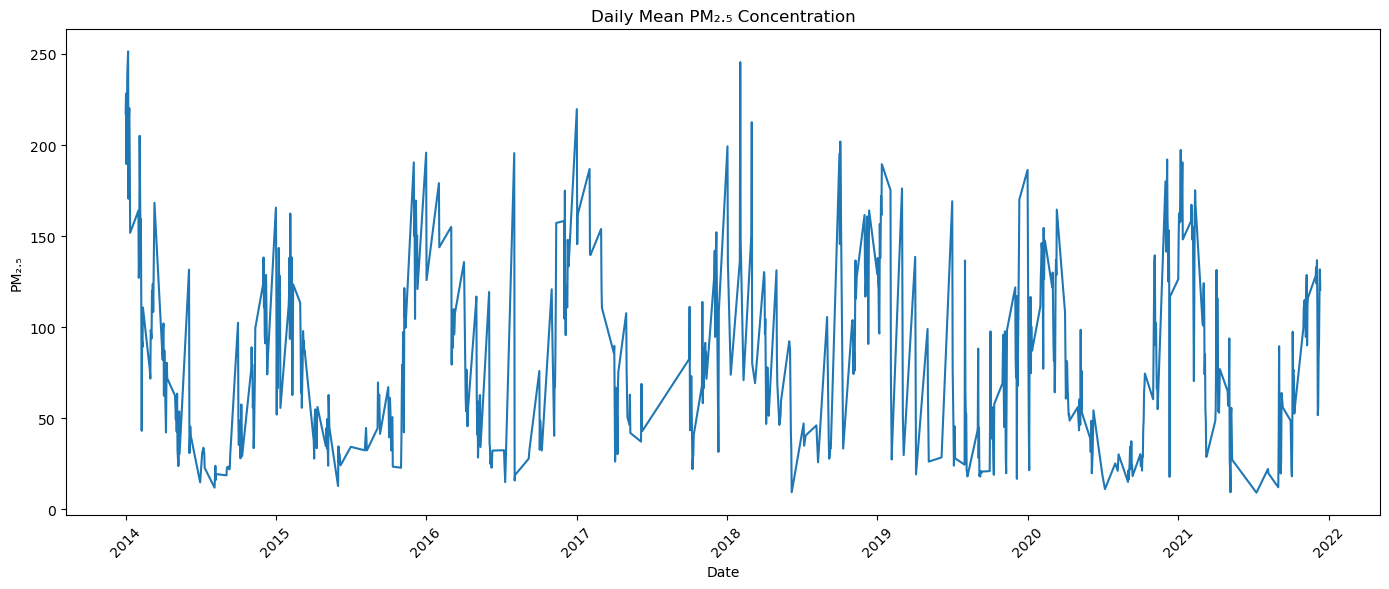

In [12]:
# ============================================================
# PART 17 — MONTHLY POLLUTION LEVEL
# ============================================================

monthly_pollution = (
    df_qc
    .groupby("Month")[pollutants]
    .mean()
)


print("\nMonthly pollution:")
print(monthly_pollution)


monthly_pollution.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "04_Monthly_Pollution.xlsx"
    )
)


# ============================================================
# PART 18 — ANNUAL POLLUTION LEVEL
# ============================================================

annual_pollution = (
    df_qc
    .groupby("Year")[pollutants]
    .mean()
)


print("\nAnnual pollution:")
print(annual_pollution)


annual_pollution.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "05_Annual_Pollution.xlsx"
    )
)


# ============================================================
# PART 19 — TIME-SERIES PLOT
# ============================================================

plt.figure(figsize=(14, 6))

daily_pm = (
    df_qc
    .groupby("Date")["PM25_daily_avg"]
    .mean()
)

plt.plot(
    daily_pm.index,
    daily_pm.values
)

plt.xlabel("Date")
plt.ylabel("PM₂.₅")
plt.title("Daily Mean PM₂.₅ Concentration")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "06_Daily_PM25_TimeSeries.png"
    ),
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Peaks indicate periods of unusually high PM2.5.
#
# Repeated seasonal peaks can indicate systematic seasonal
# variation rather than isolated pollution events.
#
# However, a time-series plot alone cannot explain WHY
# pollution increased.
#
# That is why the next section investigates meteorology.


In [13]:
# ============================================================
# PART 20 — METEOROLOGY → POLLUTION CORRELATION
# ============================================================

print("\n")
print("=" * 70)
print("PART 2 — METEOROLOGY → AIR POLLUTION CORRELATION")
print("=" * 70)


correlation_results = []


for met in meteorology:

    for pollutant in pollutants:

        temp = df_qc[
            [met, pollutant]
        ].dropna()


        if len(temp) >= 3:

            pearson_r, pearson_p = pearsonr(
                temp[met],
                temp[pollutant]
            )

            spearman_rho, spearman_p = spearmanr(
                temp[met],
                temp[pollutant]
            )

            correlation_results.append({

                "Meteorology": met,

                "Pollutant": pollutant,

                "N": len(temp),

                "Pearson_r": pearson_r,

                "Pearson_p": pearson_p,

                "Spearman_rho": spearman_rho,

                "Spearman_p": spearman_p

            })


correlation_df = pd.DataFrame(
    correlation_results
)


print(correlation_df)


correlation_df.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "07_Meteorology_Pollution_Correlation.xlsx"
    ),
    index=False
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Pearson r:
# Measures linear association.
#
# Spearman rho:
# Measures monotonic association and is less sensitive to
# non-normal data/outliers.
#
# Positive correlation:
# As meteorological variable increases, pollutant tends
# to increase.
#
# Negative correlation:
# As meteorological variable increases, pollutant tends
# to decrease.
#
# r close to +1:
# Strong positive relationship.
#
# r close to -1:
# Strong negative relationship.
#
# r close to 0:
# Weak linear relationship.
#
# p < 0.05:
# Evidence against the null hypothesis of zero association.
#
# IMPORTANT:
# Correlation DOES NOT mean causation.
#
# Example:
# If wind speed has a negative correlation with PM2.5,
# stronger winds may be associated with lower PM2.5,
# potentially because of enhanced dispersion.
#
# But the correlation alone does not prove the physical
# mechanism.





PART 2 — METEOROLOGY → AIR POLLUTION CORRELATION
             Meteorology       Pollutant     N  Pearson_r     Pearson_p  \
0         Temp_daily_avg  PM25_daily_avg  1485  -0.387200  2.628108e-54   
1         Temp_daily_avg  PM10_daily_avg  1366  -0.287350  2.225001e-27   
2         Temp_daily_avg    NO_daily_avg  1218  -0.105119  2.378029e-04   
3         Temp_daily_avg   NO2_daily_avg  1216  -0.113608  7.174712e-05   
4         Temp_daily_avg   NOX_daily_avg  1221  -0.134879  2.246722e-06   
5         Temp_daily_avg   SO2_daily_avg  1292   0.007769  7.802490e-01   
6         Temp_daily_avg    CO_daily_avg  1279   0.011925  6.700564e-01   
7         Temp_daily_avg    O3_daily_avg  1270  -0.013314  6.354900e-01   
8           RH_daily_avg  PM25_daily_avg  1516  -0.186916  2.192676e-13   
9           RH_daily_avg  PM10_daily_avg  1397  -0.156906  3.726952e-09   
10          RH_daily_avg    NO_daily_avg  1242  -0.302261  1.185181e-27   
11          RH_daily_avg   NO2_daily_avg  1225  -

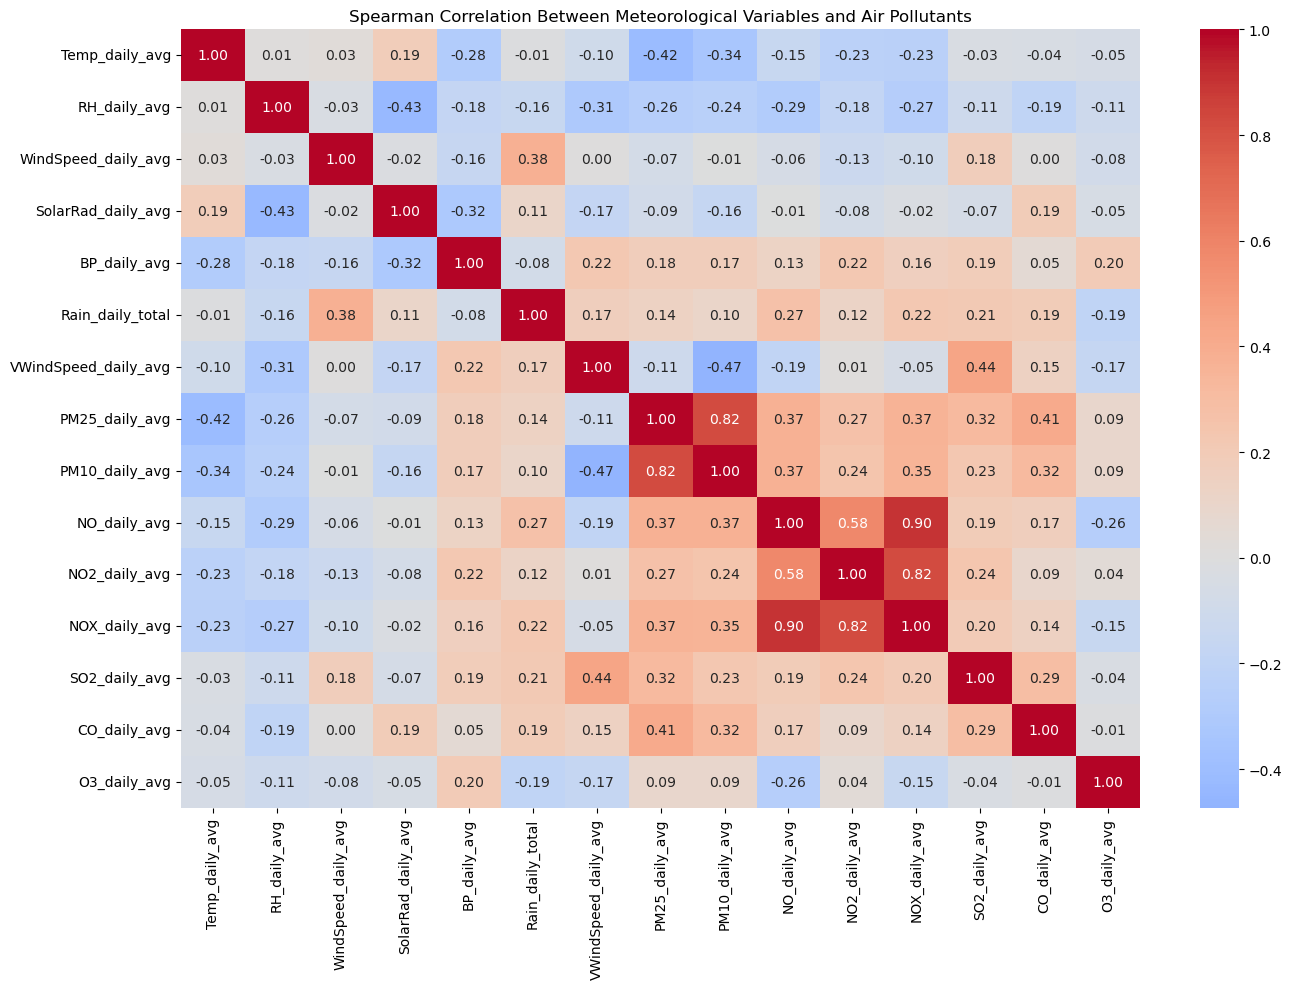



PART 3 — AOD VS PM₂.₅

AOD-PM2.5 results
N = 2647
Pearson r = 0.1099600152575442
Pearson p = 1.4124927385548866e-08
Spearman rho = 0.05412176140939464
Spearman p = 0.005348862759910943
Slope = 16.26804649880287
Intercept = 82.94099402637742
R² = 0.012091204955439345
Regression p-value = 1.4124927385548633e-08

Regression equation:
PM2.5 = 82.941 + 16.268 × AOD


In [14]:
# ============================================================
# PART 21 — CORRELATION HEATMAP
# ============================================================

corr_variables = meteorology + pollutants

corr_matrix = df_qc[
    corr_variables
].corr(method="spearman")


plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title(
    "Spearman Correlation Between Meteorological Variables "
    "and Air Pollutants"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "08_Meteorology_Pollution_Correlation_Heatmap.png"
    ),
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# IMPORTANT INTERPRETATION
# ------------------------------------------------------------
#
# Your paper should emphasize the meteorology → pollution
# relationships rather than treating every correlation as
# equally important.
#
# Example:
#
# Temperature ↔ O3
# RH ↔ PM2.5
# Wind speed ↔ PM2.5
# Rainfall ↔ PM10
#
# These relationships can be discussed individually.
#
# Wind direction is intentionally NOT included here as a
# normal numeric variable.
#
# Why?
#
# 359° and 1° are physically very close, but mathematically
# they appear far apart.
#
# Therefore wind direction requires circular/sector analysis,
# which is performed later.


# ============================================================
# PART 22 — AOD VS PM2.5
# ============================================================

print("\n")
print("=" * 70)
print("PART 3 — AOD VS PM₂.₅")
print("=" * 70)


aod_pm = df_qc[
    ["AOD", "PM25_daily_avg"]
].dropna()


x = aod_pm["AOD"]
y = aod_pm["PM25_daily_avg"]


pearson_r, pearson_p = pearsonr(x, y)

spearman_rho, spearman_p = spearmanr(x, y)

regression = linregress(x, y)


print("\nAOD-PM2.5 results")

print("N =", len(aod_pm))

print("Pearson r =", pearson_r)

print("Pearson p =", pearson_p)

print("Spearman rho =", spearman_rho)

print("Spearman p =", spearman_p)

print("Slope =", regression.slope)

print("Intercept =", regression.intercept)

print("R² =", regression.rvalue ** 2)

print("Regression p-value =", regression.pvalue)

print(
    f"\nRegression equation:\n"
    f"PM2.5 = {regression.intercept:.3f} "
    f"+ {regression.slope:.3f} × AOD"
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# This is one of the CENTRAL analyses of your study.
#
# Pearson r:
# Measures the linear relationship between satellite AOD
# and ground PM2.5.
#
# Positive r:
# Higher AOD tends to occur with higher PM2.5.
#
# R²:
# Percentage of variation in PM2.5 explained by AOD alone
# in this simple linear model.
#
# Example:
# R² = 0.40 means approximately 40% of the observed
# variation is explained by this simple model.
#
# IMPORTANT:
# Do NOT say:
# "AOD explains 40% of PM2.5 concentration everywhere."
#
# More accurate:
# "AOD alone explained approximately 40% of the variance
# in the observed PM2.5 dataset."
#
# AOD is a column-integrated aerosol optical measurement,
# whereas PM2.5 is a near-surface concentration.
#
# Therefore AOD and PM2.5 will not necessarily have a
# perfect relationship.
#
# Meteorology, boundary-layer conditions, humidity,
# aerosol vertical distribution, clouds and other factors
# can modify the relationship.
#
# This is why the next model combines AOD + meteorology.

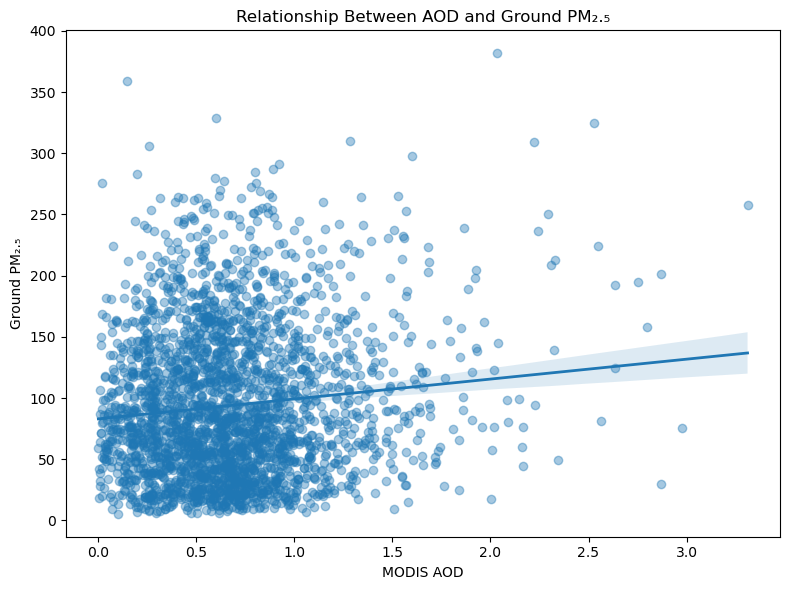

In [15]:
# ============================================================
# PART 23 — AOD VS PM2.5 SCATTERPLOT
# ============================================================

plt.figure(figsize=(8, 6))

sns.regplot(
    data=aod_pm,
    x="AOD",
    y="PM25_daily_avg",
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2}
)

plt.xlabel("MODIS AOD")
plt.ylabel("Ground PM₂.₅")
plt.title("Relationship Between AOD and Ground PM₂.₅")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "09_AOD_vs_PM25.png"
    ),
    dpi=300
)

plt.show()

In [16]:
# ============================================================
# PART 24 — AOD VS OTHER POLLUTANTS
# ============================================================

aod_pollution_results = []


for pollutant in pollutants:

    temp = df_qc[
        ["AOD", pollutant]
    ].dropna()


    if len(temp) >= 3:

        r, p = pearsonr(
            temp["AOD"],
            temp[pollutant]
        )

        rho, rho_p = spearmanr(
            temp["AOD"],
            temp[pollutant]
        )


        aod_pollution_results.append({

            "Pollutant": pollutant,

            "N": len(temp),

            "Pearson_r": r,

            "Pearson_p": p,

            "Spearman_rho": rho,

            "Spearman_p": rho_p

        })


aod_pollution_df = pd.DataFrame(
    aod_pollution_results
)


print(aod_pollution_df)


aod_pollution_df.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "10_AOD_vs_All_Pollutants.xlsx"
    ),
    index=False
)


        Pollutant     N  Pearson_r     Pearson_p  Spearman_rho  Spearman_p
0  PM25_daily_avg  2647   0.109960  1.412493e-08      0.054122    0.005349
1  PM10_daily_avg  2366   0.080523  8.815368e-05      0.014636    0.476712
2    NO_daily_avg  2020   0.037959  8.807969e-02      0.008124    0.715166
3   NO2_daily_avg  2000   0.051749  2.064521e-02     -0.007844    0.725901
4   NOX_daily_avg  2025   0.063204  4.437299e-03      0.016098    0.469067
5   SO2_daily_avg  2102   0.043152  4.791172e-02     -0.034019    0.118948
6    CO_daily_avg  2113   0.035081  1.069321e-01      0.008422    0.698808
7    O3_daily_avg  2177  -0.040716  5.750734e-02     -0.071632    0.000824


In [17]:
# ============================================================
# PART 25 — AOD VS PM2.5 BY STATION
# ============================================================

station_aod_results = []


for station, group in df_qc.groupby("Station"):

    temp = group[
        ["AOD", "PM25_daily_avg"]
    ].dropna()


    if len(temp) >= 10:

        r, p = pearsonr(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )

        rho, rho_p = spearmanr(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )

        slope, intercept, r_value, p_value, std_err = linregress(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )


        station_aod_results.append({

            "Station": station,

            "N": len(temp),

            "Pearson_r": r,

            "Pearson_p": p,

            "Spearman_rho": rho,

            "Spearman_p": rho_p,

            "Slope": slope,

            "Intercept": intercept,

            "R2": r_value ** 2

        })


station_aod_df = pd.DataFrame(
    station_aod_results
)


print("\nStation-wise AOD-PM2.5:")
print(station_aod_df)


station_aod_df.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "11_Station_Wise_AOD_PM25.xlsx"
    ),
    index=False
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Station-wise analysis is important because the AOD-PM2.5
# relationship may differ between locations.
#
# A strong relationship at one station does not automatically
# mean the same relationship exists everywhere.
#
# Differences can result from:
# - urban structure
# - emission sources
# - meteorology
# - aerosol type
# - boundary-layer conditions
# - station environment
#
# This supports the argument for spatially differentiated
# PM2.5 estimation.




Station-wise AOD-PM2.5:
              Station    N  Pearson_r  Pearson_p  Spearman_rho  Spearman_p  \
0  Chittagong_Agrabad  301   0.088571   0.125210      0.065512    0.257183   
1  Chittagong_Khulshi  232   0.031249   0.635842      0.031558    0.632507   
2          Dhaka_BARC  409   0.076993   0.120033      0.012550    0.800238   
3    Dhaka_DarusSalam  435   0.190187   0.000066      0.075166    0.117488   
4              Khulna  317   0.078135   0.165206      0.030807    0.584743   
5         Narayanganj  404   0.099973   0.044618      0.024366    0.625335   
6            Rajshahi  450   0.097360   0.038972      0.109962    0.019636   
7               Savar   99  -0.144788   0.152754     -0.191888    0.057075   

       Slope   Intercept        R2  
0  10.139362   77.252199  0.007845  
1   3.337537   67.304268  0.000977  
2  10.598622   98.953534  0.005928  
3  27.507335   80.872404  0.036171  
4  10.681839   70.493053  0.006105  
5  18.434338  114.073815  0.009995  
6  12.224027 

In [18]:
# ============================================================
# PART 26 — AOD VS PM2.5 BY SEASON
# ============================================================

season_aod_results = []


for season, group in df_qc.groupby("Season"):

    temp = group[
        ["AOD", "PM25_daily_avg"]
    ].dropna()


    if len(temp) >= 10:

        r, p = pearsonr(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )

        rho, rho_p = spearmanr(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )

        slope, intercept, r_value, p_value, std_err = linregress(
            temp["AOD"],
            temp["PM25_daily_avg"]
        )


        season_aod_results.append({

            "Season": season,

            "N": len(temp),

            "Pearson_r": r,

            "Pearson_p": p,

            "Spearman_rho": rho,

            "Spearman_p": rho_p,

            "Slope": slope,

            "Intercept": intercept,

            "R2": r_value ** 2

        })


season_aod_df = pd.DataFrame(
    season_aod_results
)


print("\nSeason-wise AOD-PM2.5:")
print(season_aod_df)


season_aod_df.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "12_Season_Wise_AOD_PM25.xlsx"
    ),
    index=False
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# If the AOD-PM2.5 relationship is stronger in one season,
# this suggests that the satellite-to-ground relationship is
# seasonally dependent.
#
# For example:
#
# Higher winter relationship could indicate more stable
# atmospheric conditions.
#
# But this should NOT be claimed automatically.
#
# The actual explanation should be supported by your
# meteorological results.



Season-wise AOD-PM2.5:
         Season    N  Pearson_r  Pearson_p  Spearman_rho  Spearman_p  \
0       Monsoon  363   0.043983   0.403436      0.053873    0.306016   
1  Post-Monsoon  623   0.040474   0.313158      0.006896    0.863610   
2   Pre-Monsoon  705   0.062633   0.096571      0.040067    0.288059   
3        Winter  956   0.117595   0.000269      0.084358    0.009067   

       Slope   Intercept        R2  
0   4.469455   37.016991  0.001934  
1   5.085288   72.329859  0.001638  
2   7.032973   77.277991  0.003923  
3  15.889058  123.824619  0.013829  


In [19]:
# ============================================================
# PART 27 — CREATE MODEL DATASET
# ============================================================

model_variables = [
    "PM25_daily_avg",
    "AOD",
    "Temp_daily_avg",
    "RH_daily_avg",
    "WindSpeed_daily_avg",
    "Rain_daily_total",
    "BP_daily_avg",
    "SolarRad_daily_avg",
    "VWindSpeed_daily_avg"
]


model_df = df_qc[
    model_variables
].dropna()


print("\nModel dataset size:", len(model_df))


# ============================================================
# PART 28 — MODEL 1: AOD ONLY
# ============================================================

print("\n")
print("=" * 70)
print("PART 4 — MODEL 1: AOD ONLY")
print("=" * 70)


X1 = model_df[
    ["AOD"]
]

y = model_df[
    "PM25_daily_avg"
]


X1 = sm.add_constant(X1)


model1 = sm.OLS(
    y,
    X1
).fit()


print(model1.summary())


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# This is the simplest PM2.5 estimation model:
#
# PM2.5 = β0 + β1 × AOD
#
# β1:
# Expected change in PM2.5 associated with a one-unit
# increase in AOD.
#
# R²:
# Variance explained by AOD alone.
#
# p-value for AOD:
# Tests whether the AOD coefficient differs significantly
# from zero.
#
# This model gives you a baseline against which more advanced
# models can be compared.



Model dataset size: 36


PART 4 — MODEL 1: AOD ONLY
                            OLS Regression Results                            
Dep. Variable:         PM25_daily_avg   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.2947
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.591
Time:                        12:26:35   Log-Likelihood:                -207.05
No. Observations:                  36   AIC:                             418.1
Df Residuals:                      34   BIC:                             421.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [20]:

# ============================================================
# PART 29 — MODEL 2: METEOROLOGY ONLY
# ============================================================

print("\n")
print("=" * 70)
print("PART 5 — MODEL 2: METEOROLOGY ONLY")
print("=" * 70)


met_predictors = [
    "Temp_daily_avg",
    "RH_daily_avg",
    "WindSpeed_daily_avg",
    "Rain_daily_total",
    "BP_daily_avg",
    "SolarRad_daily_avg",
    "VWindSpeed_daily_avg"
]


X2 = model_df[
    met_predictors
]

X2 = sm.add_constant(X2)


model2 = sm.OLS(
    y,
    X2
).fit()


print(model2.summary())


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# This model answers:
#
# "How much of the variation in PM2.5 can be statistically
# associated with meteorological conditions?"
#
# Positive coefficient:
# Higher predictor is associated with higher PM2.5,
# holding other predictors constant.
#
# Negative coefficient:
# Higher predictor is associated with lower PM2.5,
# holding other predictors constant.
#
# IMPORTANT:
# A regression coefficient is an adjusted association,
# not automatically a causal effect.



PART 5 — MODEL 2: METEOROLOGY ONLY
                            OLS Regression Results                            
Dep. Variable:         PM25_daily_avg   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     5.566
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           0.000430
Time:                        12:27:09   Log-Likelihood:                -191.51
No. Observations:                  36   AIC:                             399.0
Df Residuals:                      28   BIC:                             411.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [21]:
# ============================================================
# PART 30 — MODEL 3: AOD + METEOROLOGY
# ============================================================

print("\n")
print("=" * 70)
print("PART 6 — MODEL 3: AOD + METEOROLOGY")
print("=" * 70)


integrated_predictors = [
    "AOD",
    "Temp_daily_avg",
    "RH_daily_avg",
    "WindSpeed_daily_avg",
    "Rain_daily_total",
    "BP_daily_avg",
    "SolarRad_daily_avg",
    "VWindSpeed_daily_avg"
]


X3 = model_df[
    integrated_predictors
]

X3 = sm.add_constant(X3)


model3 = sm.OLS(
    y,
    X3
).fit()


print(model3.summary())


# ------------------------------------------------------------
# MOST IMPORTANT INTERPRETATION
# ------------------------------------------------------------
#
# This is your main integrated model:
#
# PM2.5 =
# β0
# + β1(AOD)
# + β2(Temperature)
# + β3(RH)
# + β4(Wind Speed)
# + β5(Rainfall)
# + β6(BP)
# + β7(Solar Radiation)
# + β8(VWS)
#
# Compare Model 1 and Model 3.
#
# If Model 3 has substantially higher R² and lower error,
# this suggests that meteorological information improves
# the estimation of ground PM2.5 from AOD.
#
# This is an important research finding.
#
# Example wording:
#
# "The integrated AOD–meteorological model demonstrated
# improved explanatory performance compared with the
# AOD-only model."
#
# Do not claim that the model is universally applicable
# without independent validation.




PART 6 — MODEL 3: AOD + METEOROLOGY
                            OLS Regression Results                            
Dep. Variable:         PM25_daily_avg   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     4.704
Date:                Thu, 10 Sep 2026   Prob (F-statistic):            0.00108
Time:                        12:27:51   Log-Likelihood:                -191.49
No. Observations:                  36   AIC:                             401.0
Df Residuals:                      27   BIC:                             415.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [22]:


# ============================================================
# PART 31 — MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "AOD only",
        "Meteorology only",
        "AOD + Meteorology"
    ],

    "R2": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared
    ],

    "Adjusted_R2": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj
    ],

    "AIC": [
        model1.aic,
        model2.aic,
        model3.aic
    ],

    "BIC": [
        model1.bic,
        model2.bic,
        model3.bic
    ]
})


print("\nModel comparison:")
print(model_comparison)


model_comparison.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "13_Model_Comparison.xlsx"
    ),
    index=False
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Higher adjusted R²:
# Better explanatory performance while accounting for the
# number of predictors.
#
# Lower AIC/BIC:
# Generally preferable when comparing models fitted to the
# same dataset.
#
# The integrated model is preferable only if the improvement
# is meaningful and the model remains statistically sound.
#
# More variables do NOT automatically mean a better model.


Model comparison:
               Model        R2  Adjusted_R2         AIC         BIC
0           AOD only  0.008593    -0.020566  418.103908  421.270946
1   Meteorology only  0.581868     0.477334  399.024126  411.692277
2  AOD + Meteorology  0.582270     0.458499  400.989418  415.241088


In [23]:

# ============================================================
# PART 32 — VIF MULTICOLLINEARITY
# ============================================================

print("\n")
print("=" * 70)
print("PART 7 — MULTICOLLINEARITY / VIF")
print("=" * 70)


vif_data = X3.drop(
    columns="const"
).copy()


vif_results = pd.DataFrame()


vif_results["Variable"] = vif_data.columns


vif_results["VIF"] = [

    variance_inflation_factor(
        vif_data.values,
        i
    )

    for i in range(
        vif_data.shape[1]
    )

]


print(vif_results)


vif_results.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "14_VIF.xlsx"
    ),
    index=False
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# VIF measures multicollinearity.
#
# Rough interpretation:
#
# VIF < 5:
# Usually acceptable.
#
# VIF 5–10:
# Potential concern.
#
# VIF > 10:
# Strong multicollinearity concern.
#
# High VIF means predictors contain overlapping information.
#
# Example:
# Temperature and Solar Radiation may be correlated.
#
# If VIF is very high, coefficient estimates can become
# unstable and difficult to interpret.





PART 7 — MULTICOLLINEARITY / VIF
               Variable          VIF
0                   AOD     6.198417
1        Temp_daily_avg   258.361267
2          RH_daily_avg   168.826979
3   WindSpeed_daily_avg     3.232994
4      Rain_daily_total     1.843065
5          BP_daily_avg  2115.085102
6    SolarRad_daily_avg   986.207509
7  VWindSpeed_daily_avg   210.444126


In [24]:
# ============================================================
# PART 33 — MODEL PREDICTIONS
# ============================================================

model_df["Predicted_PM25"] = model3.predict(
    X3
)


# ============================================================
# PART 34 — MODEL PERFORMANCE
# ============================================================

observed = model_df[
    "PM25_daily_avg"
]

predicted = model_df[
    "Predicted_PM25"
]


r2 = r2_score(
    observed,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        observed,
        predicted
    )
)

mae = mean_absolute_error(
    observed,
    predicted
)


print("\nIntegrated model performance:")

print("R²   =", r2)
print("RMSE =", rmse)
print("MAE  =", mae)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# R²:
# Proportion of variation explained by the model.
#
# RMSE:
# Typical prediction error, with larger errors receiving
# greater weight.
#
# MAE:
# Average absolute prediction error.
#
# Lower RMSE and MAE indicate better prediction performance.
#
# However, these are currently TRAINING performance metrics.
#
# They do NOT prove that the model will perform equally well
# on unseen locations or dates.
#
# Proper train/test or cross-validation is required for
# predictive modelling.



Integrated model performance:
R²   = 0.5822704604301028
RMSE = 49.420184431395434
MAE  = 41.45100662984783


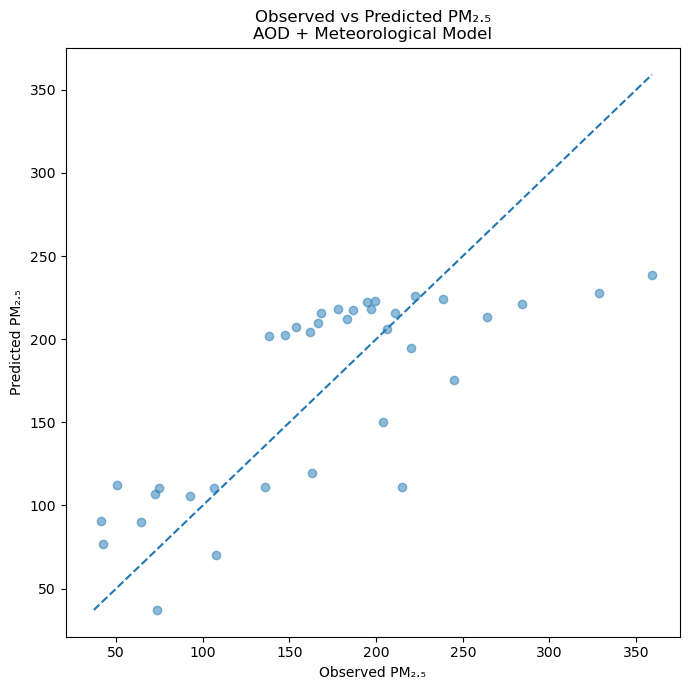

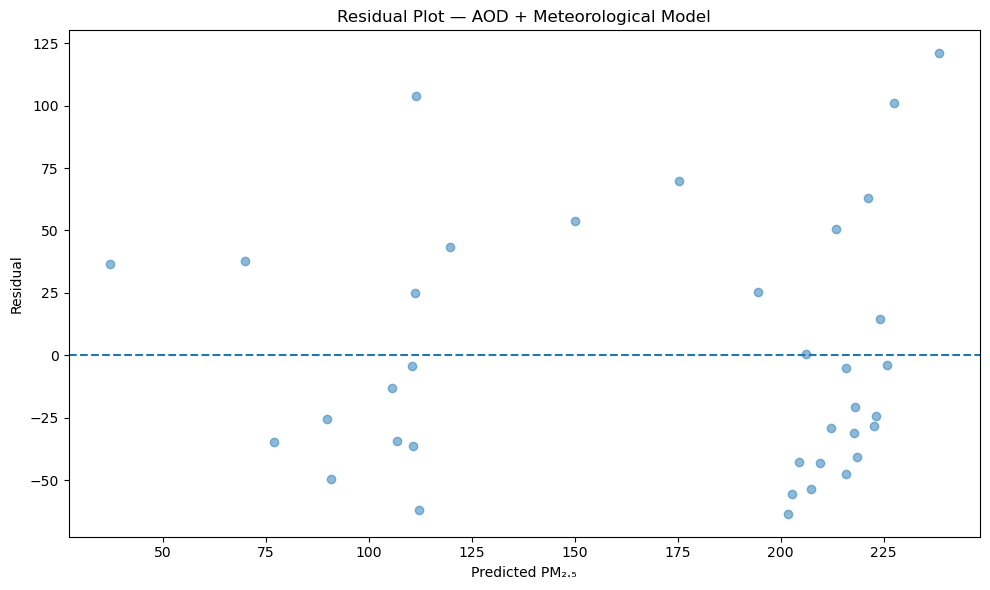

In [25]:
# ============================================================
# PART 35 — OBSERVED VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    observed,
    predicted,
    alpha=0.5
)

min_value = min(
    observed.min(),
    predicted.min()
)

max_value = max(
    observed.max(),
    predicted.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Observed PM₂.₅")
plt.ylabel("Predicted PM₂.₅")

plt.title(
    "Observed vs Predicted PM₂.₅\n"
    "AOD + Meteorological Model"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "15_Observed_vs_Predicted_PM25.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# PART 36 — RESIDUAL ANALYSIS
# ============================================================

model_df["Residual"] = (
    observed -
    predicted
)


plt.figure(figsize=(10, 6))

plt.scatter(
    predicted,
    model_df["Residual"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted PM₂.₅")
plt.ylabel("Residual")

plt.title(
    "Residual Plot — AOD + Meteorological Model"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "16_Residual_Plot.png"
    ),
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Ideally residuals should:
#
# - be centered around zero
# - show no obvious curve
# - show no strong funnel shape
#
# A strong pattern may indicate:
#
# - nonlinear relationships
# - heteroscedasticity
# - missing predictors
# - model misspecification
#
# This is important before making strong modelling claims.

In [26]:
# ============================================================
# PART 37 — WIND DIRECTION SECTORS
# ============================================================

print("\n")
print("=" * 70)
print("PART 8 — WIND DIRECTION ANALYSIS")
print("=" * 70)


def wind_sector(degree):

    if pd.isna(degree):
        return np.nan

    if degree >= 337.5 or degree < 22.5:
        return "N"

    elif degree < 67.5:
        return "NE"

    elif degree < 112.5:
        return "E"

    elif degree < 157.5:
        return "SE"

    elif degree < 202.5:
        return "S"

    elif degree < 247.5:
        return "SW"

    elif degree < 292.5:
        return "W"

    else:
        return "NW"


df_qc["Wind_Sector"] = (
    df_qc[
        "WindDir_daily_circular_mean"
    ]
    .apply(wind_sector)
)


print(
    df_qc["Wind_Sector"]
    .value_counts()
)


# ============================================================
# PART 38 — POLLUTION BY WIND SECTOR
# ============================================================

wind_pollution = (
    df_qc
    .groupby("Wind_Sector")[pollutants]
    .agg(
        ["count", "mean", "median", "std"]
    )
)


print("\nPollution by wind sector:")
print(wind_pollution)


wind_pollution.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "17_Wind_Sector_Pollution.xlsx"
    )
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# If PM2.5 is systematically higher under a particular wind
# sector, this indicates an association between wind direction
# and pollution concentration.
#
# Example:
#
# If PM2.5 is highest under the NW sector, investigate whether
# relevant upwind emission sources exist to the northwest.
#
# BUT:
#
# Wind sector alone does NOT prove the source.
#
# A proper source-attribution analysis requires additional
# information such as:
#
# - emission-source locations
# - land use
# - industrial locations
# - traffic
# - back trajectories
# - source apportionment methods
#
# Therefore use language such as:
#
# "higher concentrations were associated with winds from..."
#
# rather than:
#
# "the pollution came from..."




PART 8 — WIND DIRECTION ANALYSIS
Wind_Sector
SW    212
N     208
S     152
E     142
SE    118
NW    118
W     109
NE     94
Name: count, dtype: int64

Pollution by wind sector:
            PM25_daily_avg                                    PM10_daily_avg  \
                     count        mean      median        std          count   
Wind_Sector                                                                    
E                      142   90.637838   79.816153  58.811243            137   
N                      208  114.435466  109.604940  57.473085            183   
NE                      94  111.251256  108.935928  55.786965             87   
NW                     118  129.920853  122.947917  62.633437            107   
S                      152   88.141094   64.836833  59.214791            143   
SE                     118   64.962691   51.825828  46.770612            112   
SW                     212  114.444653  107.025625  66.159331            186   
W                   

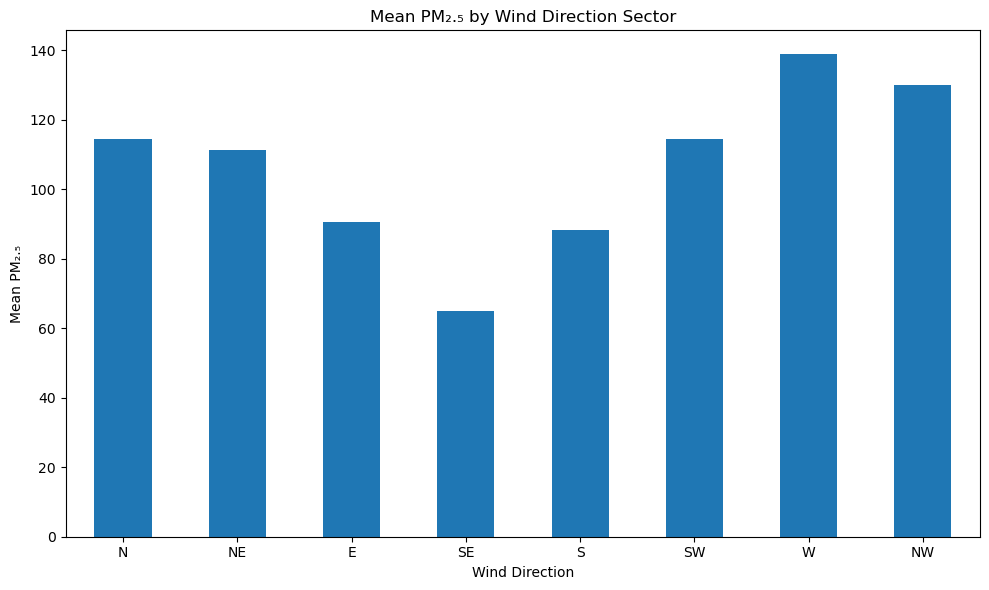

In [27]:
# ============================================================
# PART 39 — WIND SECTOR PM2.5 BAR CHART
# ============================================================

wind_pm = (
    df_qc
    .groupby("Wind_Sector")[
        "PM25_daily_avg"
    ]
    .mean()
)


sector_order = [
    "N",
    "NE",
    "E",
    "SE",
    "S",
    "SW",
    "W",
    "NW"
]


wind_pm = wind_pm.reindex(
    sector_order
)


plt.figure(figsize=(10, 6))

wind_pm.plot(
    kind="bar"
)

plt.xlabel("Wind Direction")

plt.ylabel("Mean PM₂.₅")

plt.title(
    "Mean PM₂.₅ by Wind Direction Sector"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "18_PM25_by_Wind_Sector.png"
    ),
    dpi=300
)

plt.show()

In [28]:

# ============================================================
# PART 40 — CITY/STATION-WISE POLLUTION
# ============================================================

print("\n")
print("=" * 70)
print("PART 9 — STATION/CITY-WISE POLLUTION")
print("=" * 70)


city_pollution = (
    df_qc
    .groupby("Station")[pollutants]
    .agg(
        ["count", "mean", "median", "std", "max"]
    )
)


print(city_pollution)


city_pollution.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "19_Station_Wise_Pollution.xlsx"
    )
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# This section compares pollution conditions among monitoring
# locations.
#
# Report pollutant-specific statistics.
#
# For example:
#
# Station A has higher mean PM2.5 than Station B.
#
# This is preferable to immediately creating one arbitrary
# "overall pollution score."
#
# Different pollutants have different health/environmental
# meanings and units.
#
# A combined index should only be created if you have a clear
# methodological basis for doing so.



PART 9 — STATION/CITY-WISE POLLUTION
                   PM25_daily_avg                                     \
                            count        mean      median        std   
Station                                                                
Chittagong_Agrabad            301   82.545209   81.056667  41.935805   
Chittagong_Khulshi            232   69.171379   66.733125  43.065906   
Dhaka_BARC                    409  106.722209  105.255000  58.065015   
Dhaka_DarusSalam              435  100.935405   86.591304  62.599835   
Khulna                        317   78.961304   63.302500  53.941996   
Narayanganj                   404  126.421246  121.568409  76.335707   
Rajshahi                      450   75.205832   67.796984  49.738809   
Savar                          99  102.758808   87.635000  64.433595   

                               PM10_daily_avg                          \
                           max          count        mean      median   
Station               

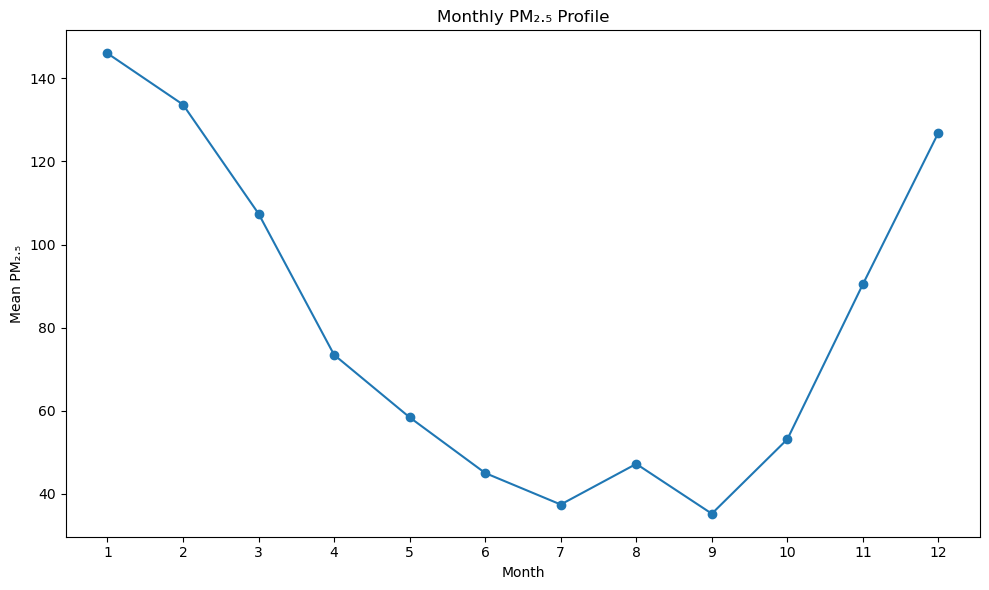

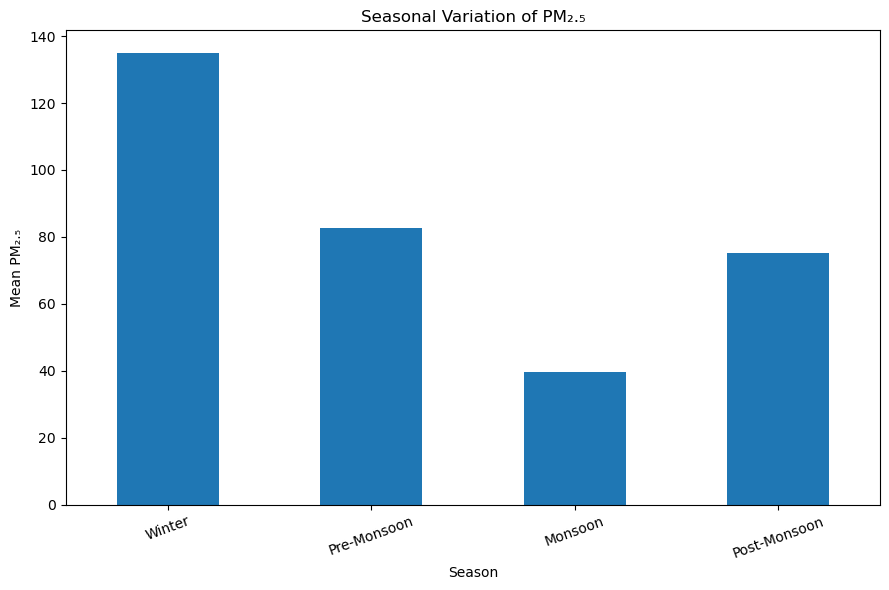

In [29]:

# ============================================================
# PART 41 — PM2.5 MONTHLY PROFILE
# ============================================================

monthly_pm = (
    df_qc
    .groupby("Month")[
        "PM25_daily_avg"
    ]
    .mean()
)


plt.figure(figsize=(10, 6))

plt.plot(
    monthly_pm.index,
    monthly_pm.values,
    marker="o"
)

plt.xlabel("Month")

plt.ylabel("Mean PM₂.₅")

plt.title(
    "Monthly PM₂.₅ Profile"
)

plt.xticks(
    range(1, 13)
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "20_Monthly_PM25_Profile.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# PART 42 — SEASONAL PM2.5
# ============================================================

season_order = [
    "Winter",
    "Pre-Monsoon",
    "Monsoon",
    "Post-Monsoon"
]


season_pm = (
    df_qc
    .groupby("Season")[
        "PM25_daily_avg"
    ]
    .mean()
    .reindex(season_order)
)


plt.figure(figsize=(9, 6))

season_pm.plot(
    kind="bar"
)

plt.xlabel("Season")

plt.ylabel("Mean PM₂.₅")

plt.title(
    "Seasonal Variation of PM₂.₅"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "21_Seasonal_PM25.png"
    ),
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Compare the seasonal means.
#
# If Winter has the highest PM2.5:
#
# You can investigate whether this coincides with:
# - lower wind speed
# - lower rainfall
# - higher atmospheric stability
# - different emission patterns
#
# However, the seasonal difference itself does not prove
# which mechanism caused it.
#
# Use the meteorological analysis to support the explanation.

In [30]:
# ============================================================
# PART 43 — PM2.5 / PM10 RATIO
# ============================================================

df_qc["PM25_PM10_Ratio"] = (
    df_qc["PM25_daily_avg"] /
    df_qc["PM10_daily_avg"]
)


ratio_stats = (
    df_qc[
        "PM25_PM10_Ratio"
    ].describe()
)


print("\nPM2.5/PM10 ratio:")
print(ratio_stats)


ratio_stats.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "22_PM25_PM10_Ratio.xlsx"
    )
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# The PM2.5/PM10 ratio describes the relative contribution
# of fine particles to total measured particulate matter.
#
# Higher ratios indicate a greater fine-particle fraction.
#
# Lower ratios indicate relatively more coarse particles.
#
# Do NOT use this ratio alone to identify a pollution source.
#
# Source interpretation requires additional evidence.


# ============================================================
# PART 44 — SAVE CLEAN DATASET
# ============================================================

clean_output = os.path.join(
    OUTPUT_FOLDER,
    "00_Clean_QC_Dataset.xlsx"
)


df_qc.to_excel(
    clean_output,
    index=False
)


print("\nClean dataset saved:")
print(clean_output)



PM2.5/PM10 ratio:
count    2366.000000
mean        0.643340
std         0.667107
min         0.031519
25%         0.449100
50%         0.558771
75%         0.679613
max        13.273822
Name: PM25_PM10_Ratio, dtype: float64

Clean dataset saved:
C:\Users\Juvair\Desktop\Job Application CV's\BUET_RA\Results\00_Clean_QC_Dataset.xlsx


In [31]:

# ============================================================
# PART 43 — PM2.5 / PM10 RATIO
# ============================================================

df_qc["PM25_PM10_Ratio"] = (
    df_qc["PM25_daily_avg"] /
    df_qc["PM10_daily_avg"]
)


ratio_stats = (
    df_qc[
        "PM25_PM10_Ratio"
    ].describe()
)


print("\nPM2.5/PM10 ratio:")
print(ratio_stats)


ratio_stats.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "22_PM25_PM10_Ratio.xlsx"
    )
)


# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# The PM2.5/PM10 ratio describes the relative contribution
# of fine particles to total measured particulate matter.
#
# Higher ratios indicate a greater fine-particle fraction.
#
# Lower ratios indicate relatively more coarse particles.
#
# Do NOT use this ratio alone to identify a pollution source.
#
# Source interpretation requires additional evidence.


PM2.5/PM10 ratio:
count    2366.000000
mean        0.643340
std         0.667107
min         0.031519
25%         0.449100
50%         0.558771
75%         0.679613
max        13.273822
Name: PM25_PM10_Ratio, dtype: float64


In [33]:
 #============================================================
# PART 44 — SAVE CLEAN DATASET
# ============================================================

clean_output = os.path.join(
    OUTPUT_FOLDER,
    "00_Clean_QC_Dataset.xlsx"
)


df_qc.to_excel(
    clean_output,
    index=False
)


print("\nClean dataset saved:")
print(clean_output)


# ============================================================
# PART 45 — EXPORT MODEL SUMMARY
# ============================================================

model_summary = pd.DataFrame({

    "Metric": [
        "AOD-only R2",
        "Meteorology-only R2",
        "Integrated R2",
        "Integrated Adjusted R2",
        "Integrated RMSE",
        "Integrated MAE"
    ],

    "Value": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model3.rsquared_adj,
        rmse,
        mae
    ]
})


model_summary.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "23_Final_Model_Summary.xlsx"
    ),
    index=False
)


# ============================================================
# PART 46 — SAVE INTEGRATED MODEL COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({

    "Variable": model3.params.index,

    "Coefficient": model3.params.values,

    "P_value": model3.pvalues.values,

    "Std_Error": model3.bse.values,

    "CI_Lower": model3.conf_int()[0].values,

    "CI_Upper": model3.conf_int()[1].values

})


print("\nIntegrated model coefficients:")
print(coefficients)


coefficients.to_excel(
    os.path.join(
        OUTPUT_FOLDER,
        "24_Integrated_Model_Coefficients.xlsx"
    ),
    index=False
)



# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Coefficient:
# Direction and magnitude of the adjusted association.
#
# P-value:
# Statistical evidence for the coefficient.
#
# Confidence interval:
# Range of plausible coefficient values under the model.
#
# If the confidence interval crosses zero, the evidence for
# a non-zero association is weaker.
#
# Always report the coefficient together with uncertainty,
# not only the p-value.



Clean dataset saved:
C:\Users\Juvair\Desktop\Job Application CV's\BUET_RA\Results\00_Clean_QC_Dataset.xlsx

Integrated model coefficients:
               Variable  Coefficient   P_value    Std_Error     CI_Lower  \
0                 const    38.804543  0.982715  1774.555965 -3602.283539   
1                   AOD    -4.996555  0.872995    30.961203   -68.523696   
2        Temp_daily_avg     9.368824  0.214817     7.375311    -5.764064   
3          RH_daily_avg    -0.214498  0.935292     2.617453    -5.585068   
4   WindSpeed_daily_avg   -36.831364  0.082483    20.422363   -78.734592   
5      Rain_daily_total   -36.617896  0.515605    55.582918  -150.664624   
6          BP_daily_avg     0.084218  0.964556     1.877717    -3.768539   
7    SolarRad_daily_avg    -0.031543  0.940150     0.416220    -0.885557   
8  VWindSpeed_daily_avg  -297.748573  0.347409   311.356983  -936.600333   

      CI_Upper  
0  3679.892625  
1    58.530585  
2    24.501711  
3     5.156072  
4     5.071865

In [34]:
# ============================================================
# PART 47 — FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 70)
print("ANALYSIS COMPLETED")
print("=" * 70)

print("\nResults saved in:")
print(OUTPUT_FOLDER)

print("\nMain outputs include:")

print("01  Descriptive statistics")
print("02  Station-wise statistics")
print("03  Seasonal statistics")
print("04  Monthly pollution")
print("05  Annual pollution")
print("06  PM2.5 time series")
print("07  Meteorology-pollution correlation")
print("08  Correlation heatmap")
print("09  AOD vs PM2.5")
print("10  AOD vs pollutants")
print("11  Station-wise AOD-PM2.5")
print("12  Seasonal AOD-PM2.5")
print("13  Model comparison")
print("14  VIF")
print("15  Observed vs predicted")
print("16  Residual analysis")
print("17  Wind-sector pollution")
print("18  PM2.5 by wind sector")
print("19  Station-wise pollution")
print("20  Monthly PM2.5")
print("21  Seasonal PM2.5")
print("22  PM2.5/PM10 ratio")
print("23  Final model summary")
print("24  Integrated model coefficients")



ANALYSIS COMPLETED

Results saved in:
C:\Users\Juvair\Desktop\Job Application CV's\BUET_RA\Results

Main outputs include:
01  Descriptive statistics
02  Station-wise statistics
03  Seasonal statistics
04  Monthly pollution
05  Annual pollution
06  PM2.5 time series
07  Meteorology-pollution correlation
08  Correlation heatmap
09  AOD vs PM2.5
10  AOD vs pollutants
11  Station-wise AOD-PM2.5
12  Seasonal AOD-PM2.5
13  Model comparison
14  VIF
15  Observed vs predicted
16  Residual analysis
17  Wind-sector pollution
18  PM2.5 by wind sector
19  Station-wise pollution
20  Monthly PM2.5
21  Seasonal PM2.5
22  PM2.5/PM10 ratio
23  Final model summary
24  Integrated model coefficients
